# Cleaning & EDA

This section aims at getting the first limpse at how our cloud data looks like.


The specific tasks are as follows:

1. For the 3 labeled images, plot the expert labels for the presence or absence of clouds according to a map (i.e. use the X, Y coordinates).

2. Explore the **relationships** between the radiances of different angles, both visually and quantitatively. Do you notice differences between the two classes (cloud, no cloud) based on the radiances? Are there differences based on the features (CORR, NDAI, SD)?
   
3. **Split** your data into training, validation, and test sets (or training and test, with some cross-validation scheme over the training set). Justify your choice of split based on how it reflects the challenges with possible future applications of your cloud detection algorithm.

4. As is common when dealing with real world data, these images may have imperfections that you’ll need to **clean up**.

## 💡 Takeaway 

I put the key conclusion at the very top of this notebook for convenience.

**Findings**:

---
1. Unlabeled data exists in boundaries between cloud and no cloud.
  
2. **Multi-angle radiances are strongly correlated within an image**. When restricting to cloud pixels, the radiance-angle correlation tends to decrease compared to non-cloud pixels, suggesting clouds introduce more angular variability / scattering differences across views.

3.	**Engineered features show clear class differences**. In the labeled data, **NDAI and SD** are higher for cloud pixels than non-cloud pixels, and two-sample t-tests show these differences are statistically strong.

4.	Feature complementarity: NDAI, SD, and CORR are **not highly linearly correlated** with each other, so they likely capture different aspects of the scene. A single feature may be insufficient, but combining them should improve prediction.

5.	Note on **CORR**: CORR also differs significantly by class in the labeled image(s), but the direction may not always match the initial “surface vs cloud” intuition. Generally, high values of CORR suggest either clear (cloud-free) conditions or the presence of low altitude cloud. Out of three labeled images, we have 2 images (O013257.npz and O012791.npz) where the mean CORR in cloud points is significantly higher than non-cloud points. It implies `CORR` alone can not be predictive enough.

6. Extremely high radiances exists. Interestingly, conditioning on cloud label, radiance in non-cloud points tends to be higher.

**Cleaing:**

--- 

I construct a image-level cleaning function, which involves:
+ **drop duplicate**:  based on (x,y) coordinate

+ **drop missing values**: from my inspection, it's rare to have missing values. For generaliztion, if one image has missing values, I choose to raise warning and drop that row directly
  
+ **sanity check**:
  + label range: only keep the valid label
  + radiance range: only keep the non-negative radiance
  + SD range: only keep the non-negative SD
  + CORR and NDAI range: only keep values between -1.2 and 1.2 (theoretial range should be -1 and 1 but allowing for small outilers)

**Splitting:**

---

I leave two splitting options as judgment call in `prepare_data`:

**Option 1: split by image**

+ Train: Image 1
+ Val: Image 2
+ Test: Image 3

**Option 2: split by blocks [Give up]**

+ divid two images into $n \times n$ blocks and split them to train and val splits
+ the remaining whole image as the test sets.


> **Judgment calls**:
> the choice of $n$ in grid size in block-based split
> Which image for test, which for train/val? 

**Update**: 
+ finally we abandoned this method due to substantial risk of spatial data leakage.

Also, in the function, I include

+ **Whether to drop unlabeled data** ( For classification, it's a must)
+ **Map the class label from {-1,1} to {0,1}** (for most of the classification model, the target column is by default set as 0/1).
+ **Remove outliers** : remove outliers based on Z-score within the training set (fit on train, apply to val/test)
+ **Standardize**:
  Use either:
  + StandardScaler() → z-score
  + RobustScaler() → median/IQR (often better for SD/radiance features)

## Domain problem formulation

The goal of this lab is to explore remote sensing images and develop cloud detection algorithms in the polar regions using radiance data collected by the Multi-angle Imaging SpectroRadiometer (MISR) sensor aboard NASA’s Terra satellite. The MISR sensor was developed to take advantage of the fact that clouds are at a different altitude than the polar region surface. Unlike traditional multispectral sensors that take measurements in a single view, the MISR sensor comprises nine cameras.


## Review background information

### Information on data collecton

Overall we have 164 images, only 3 of which will have ``expert labels''. The unlabeled images will enable us to experiment with transfer learning and pre-training to facilitate the classification task. Except the label, we have **10** features in total. Our observation unit is indeed at the **pixel** level.


### Data dictionary

0. $y$ coordinate 

1. $x$ coordinate

2. `NDAI`: normalized difference angular index: quantifies the normalized difference in radiance between two viewing angles (Df and An), capturing angular scattering behavior, where larger values indicate cloud presence due to stronger directional reflectance.

3. `SD`: within-block standard deviation of radiance values for the nadir (An) camera, captures the local spatial variability of radiance, where low values indicate smooth surfaces and higher values suggest textured structures such as clouds.

4. `CORR`: linear correlation of radiance measurements between different viewing angles, measures the angular consistency of spatial radiance patterns across viewing angles, where high values indicate stable surface reflections and low values suggest cloud-induced angular variation.

5. `Radiance angle DF`: radiance from zenith viewing angles of 70.5 in the forward direction

6. `Radiance angle CF`: radiance from zenith viewing angles of 60.0 in the forward direction

7. `Radiance angle BF`: radiance from zenith viewing angles of 45.6 in the forward direction

8. `Radiance angle AF`: radiance fromzenith viewing angles of 26.1 in the forward direction

9.  `Radiance angle AN`: radiance from nadir viewing angle in the forward direction

10. `expert label` ($+1$: cloud, $-1$: not cloud, $0$: unlabeled)



## Step 1: Loading data

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

In [3]:
with np.load(os.path.join('..', 'data', 'O013257.npz')) as data: 
    df1 = dict(data)['arr_0']

with np.load(os.path.join('..', 'data', 'O013490.npz')) as data: 
    df2 = dict(data)['arr_0']

with np.load(os.path.join('..', 'data', 'O012791.npz')) as data: 
    df3 = dict(data)['arr_0']

In [4]:
df1.shape, df2.shape, df3.shape

((115000, 11), (115032, 11), (114973, 11))

## Step 2: First glimpse
Get the first look at the how the three labeled image looks like

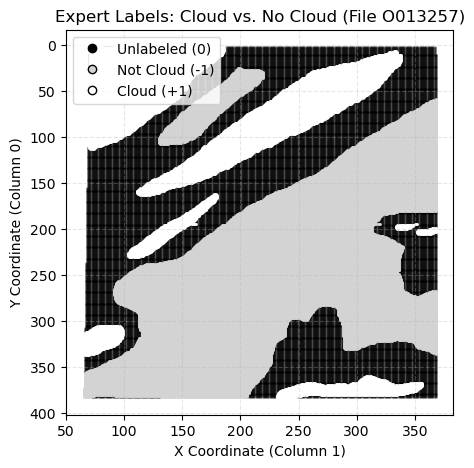

In [5]:
# Column 0: y coordinate, Column 1: x coordinate, Column 10: expert label
y_coords = df1[:, 0]
x_coords = df1[:, 1]
labels = df1[:, 10]

plt.figure(figsize=(5, 5))

plt.scatter(x_coords[labels == 0], y_coords[labels == 0], 
            color='black', s=1, label='Unlabeled (0)', alpha=0.3)
plt.scatter(x_coords[labels == -1], y_coords[labels == -1], 
            color='lightgray', s=1, label='Not Cloud (-1)')
plt.scatter(x_coords[labels == 1], y_coords[labels == 1], 
            color='white', s=1, label='Cloud (+1)')

plt.gca().invert_yaxis()  # Invert Y because (0,0) is usually top-left in images
plt.title('Expert Labels: Cloud vs. No Cloud (File O013257)')
plt.xlabel('X Coordinate (Column 1)')
plt.ylabel('Y Coordinate (Column 0)')
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='black', markersize=6,
                markeredgecolor='black',
           label='Unlabeled (0)'),

    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='lightgray', markersize=6, markeredgecolor='black',
           label='Not Cloud (-1)'),

    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='white', markeredgecolor='black',
           markersize=6, label='Cloud (+1)')  
] # add markersize and markeredgecolor to make the legend markers more visible

plt.legend(handles=legend_elements)
plt.grid(True, linestyle='--', alpha=0.3)

plt.savefig("../figs/O013257", dpi=300)
plt.show()

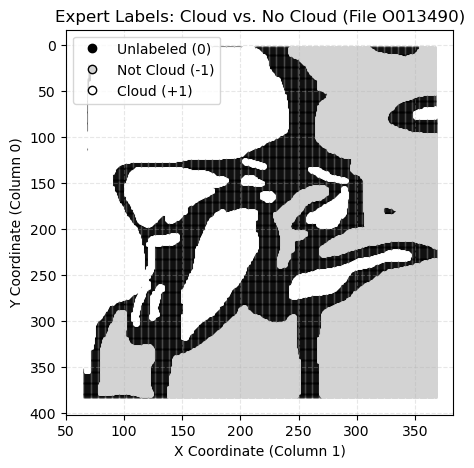

In [6]:
# Column 0: y coordinate, Column 1: x coordinate, Column 10: expert label
y_coords = df2[:, 0]
x_coords = df2[:, 1]
labels = df2[:, 10]

plt.figure(figsize=(5, 5))

plt.scatter(x_coords[labels == 0], y_coords[labels == 0], 
            color='black', s=1, label='Unlabeled (0)', alpha=0.3)
plt.scatter(x_coords[labels == -1], y_coords[labels == -1], 
            color='lightgray', s=1, label='Not Cloud (-1)')
plt.scatter(x_coords[labels == 1], y_coords[labels == 1], 
            color='white', s=1, label='Cloud (+1)')

plt.gca().invert_yaxis()  # Invert Y because (0,0) is usually top-left in images
plt.title('Expert Labels: Cloud vs. No Cloud (File O013490)')
plt.xlabel('X Coordinate (Column 1)')
plt.ylabel('Y Coordinate (Column 0)')

legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='black', markersize=6,
                markeredgecolor='black',
           label='Unlabeled (0)'),

    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='lightgray', markersize=6, markeredgecolor='black',
           label='Not Cloud (-1)'),

    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='white', markeredgecolor='black',
           markersize=6, label='Cloud (+1)')  
]

plt.legend(handles=legend_elements)
plt.grid(True, linestyle='--', alpha=0.3)

plt.savefig("../figs/O013490", dpi=300)
plt.show()

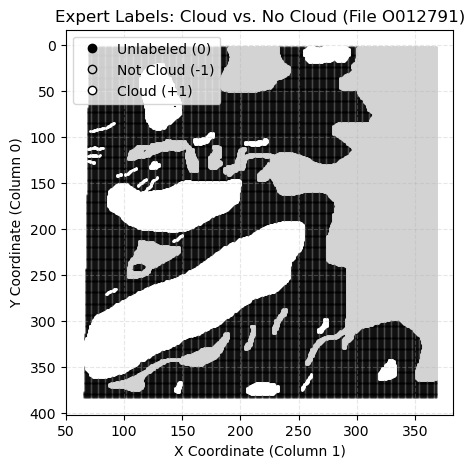

In [7]:
# Column 0: y coordinate, Column 1: x coordinate, Column 10: expert label
y_coords = df3[:, 0]
x_coords = df3[:, 1]
labels = df3[:, 10]

plt.figure(figsize=(5, 5))

# We plot them separately to create a clear legend
plt.scatter(x_coords[labels == 0], y_coords[labels == 0], 
            color='black', s=1, label='Unlabeled (0)', alpha=0.3)
plt.scatter(x_coords[labels == -1], y_coords[labels == -1], 
            color='lightgray', s=1, label='Not Cloud (-1)')
plt.scatter(x_coords[labels == 1], y_coords[labels == 1], 
            color='white', s=1, label='Cloud (+1)')

plt.gca().invert_yaxis()  # Invert Y because (0,0) is usually top-left in images
plt.title('Expert Labels: Cloud vs. No Cloud (File O012791)')
plt.xlabel('X Coordinate (Column 1)')
plt.ylabel('Y Coordinate (Column 0)')
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='black', markersize=6,
                markeredgecolor='black',
           label='Unlabeled (0)'),

    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='lightgray', markersize=6, markeredgecolor='black',
           label='Not Cloud (-1)'),

    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='white', markeredgecolor='black',
           markersize=6, label='Cloud (+1)')  
]
plt.legend(handles=legend_elements)
plt.grid(True, linestyle='--', alpha=0.3)
    
plt.savefig("../figs/O012791", dpi=300)
plt.show()


## Step 3: Data Cleaning

we first go through the three labeled images, about 
+ their missingness
+ basic value range
+ variable types
+ column names

In [8]:
# start with df1 
# transform the numpy array into a pandas dataframe for easier analysis
column_names = [
    "y_coord",
    "x_coord",
    "NDAI",
    "SD",
    "CORR",
    "radiance_DF",
    "radiance_CF",
    "radiance_BF",
    "radiance_AF",
    "radiance_AN",
    "label"
]
df1 = pd.DataFrame(df1, columns=column_names)
df1.head(20)

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,label
0,2.0,70.0,0.528076,1820.998779,0.900904,22692.50,19834.00,11228.50,8536.50,7008.25,0.0
1,2.0,71.0,0.593831,1169.416504,0.473416,23461.00,18388.50,11575.25,8993.25,5978.75,1.0
2,2.0,72.0,0.550953,1376.460571,0.861363,23831.75,16752.50,12560.25,9570.75,6900.00,1.0
3,2.0,73.0,0.550160,1389.984863,0.687417,23185.75,15590.75,14639.50,8372.50,6728.25,1.0
4,2.0,74.0,0.615813,1388.641357,0.486022,23047.75,16095.25,12771.50,7136.00,5480.00,1.0
5,2.0,75.0,0.599688,1648.248657,0.766353,23816.75,16542.50,11906.00,6817.25,5960.00,1.0
6,2.0,76.0,0.610407,1721.405640,0.876248,22545.50,15483.50,10714.75,5835.00,5454.25,1.0
7,2.0,77.0,0.620928,1257.533081,0.790170,22437.50,17329.50,10950.25,8092.00,5247.25,1.0
8,2.0,78.0,0.446301,1204.977661,0.783406,22331.25,18433.75,13120.25,10536.50,8549.25,1.0
9,2.0,79.0,0.376849,1743.536987,0.901814,22287.75,18948.50,14851.50,12309.50,10087.25,1.0


In [9]:
# missing values in df1
df1.isnull().sum()

y_coord        0
x_coord        0
NDAI           0
SD             0
CORR           0
radiance_DF    0
radiance_CF    0
radiance_BF    0
radiance_AF    0
radiance_AN    0
label          0
dtype: int64

We have no missing values in df1 (O013257.npz)

In [10]:
df1.describe()

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,label
count,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000
mean,193.012591,217.952287,0.163099,498.951855,0.540242,27633.237495,25899.689137,23939.927862,21914.087820,20185.363066,-0.259913
std,110.280751,86.910398,0.074897,721.752672,0.405618,4248.335502,4679.435297,4748.703339,4540.349484,4155.127877,0.740492
min,2.000000,65.000000,-0.158468,14.607972,-0.942551,6293.750000,4464.750000,3588.000000,3215.500000,3272.750000,-1.000000
25%,98.000000,143.000000,0.123142,48.245229,0.277339,26535.000000,25114.312500,23414.250000,21660.875000,20217.937500,-1.000000
50%,193.000000,218.000000,0.150698,194.343452,0.685812,28930.750000,27419.000000,25729.125000,23781.250000,21663.875000,0.000000
75%,289.000000,293.000000,0.175175,663.256058,0.873131,30356.500000,28825.750000,26767.750000,24349.500000,22368.062500,0.000000
max,383.000000,368.000000,0.724288,6695.496094,0.983018,48439.687500,34377.750000,33268.250000,32085.000000,30824.500000,1.000000


**Value range:** 

all the predicators are numerical variables.

Based on the definition:

`NADI`: should usually be in [-1,1] (allow small numerical spills)

`SD`: should be >=0

`CORR`: should be in [-1,1]

`Radiance`: should be >=0


---

Based on the basic description:

three expert features have different scalars with 5 radiances, one potential judgement call can be to stanardarized them before modelling.

In [11]:
# define sanity check function to check if the values are within expected ranges
def sanity_check(df):
    
    # Check if labels are only -1, 0, or 1
    if not df['label'].isin([-1, 0, 1]).all():
        print("Sanity Check Failed: label contains invalid values")
    
    # Check if radiance values are non-negative
    radiance_columns = ['radiance_DF', 'radiance_CF', 'radiance_BF', 'radiance_AF', 'radiance_AN']
    for col in radiance_columns:
        if not (df[col] >= 0).all():
            print(f"Sanity Check Failed: {col} contains negative values")

    # Check if NADI values are within a reasonable range (e.g., -1 to 1)(allowing for some outliers)
    if not ((df['NDAI'] >= -1) & (df['NDAI'] <= 1)).all():
        print("Sanity Check Failed: NDAI contains values outside the expected range [-1, 1]")
    # Check if SD values are non-negative
    if not (df['SD'] >= 0).all():
        print("Sanity Check Failed: SD contains negative values")
    # Check if CORR values are between -1 and 1
    if not ((df['CORR'] >= -1) & (df['CORR'] <= 1)).all():
        print("Sanity Check Failed: CORR contains values outside the expected range [-1, 1]")
    print("Sanity Check Passed")

In [12]:
sanity_check(df1)

Sanity Check Passed


**Check potential duplicated pixel unit**

with (x,y) coordinate, theoretically we can identify the unique pixel unit.

In [13]:
df1.duplicated(subset=['y_coord', 'x_coord']).sum()

np.int64(0)

**Basic distribution of predictors**

/tmp/ipykernel_1990521/3163285886.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([tick_label_map.get(c, c) for c in feature_cols], rotation=35, ha='right')


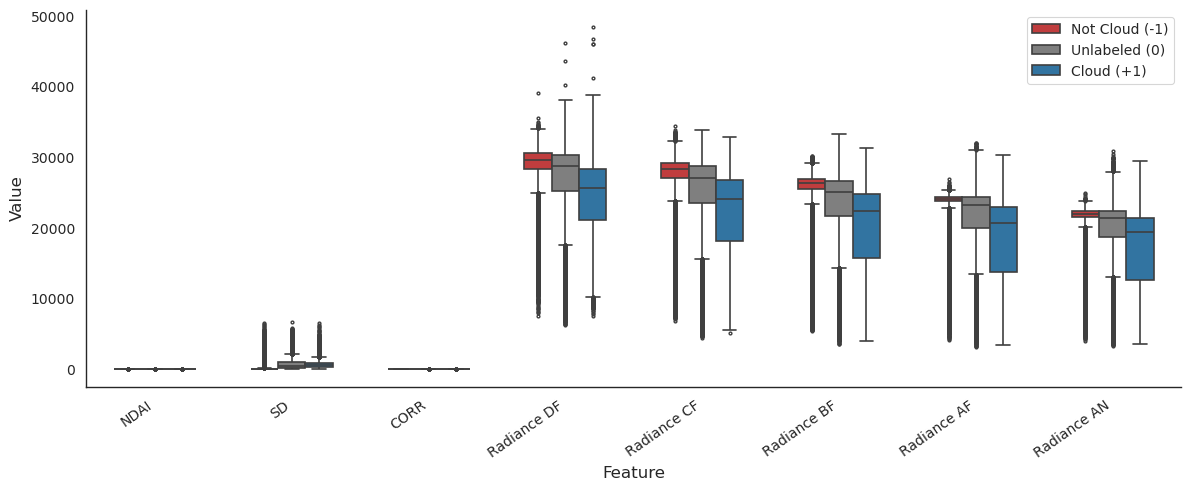

In [14]:
# --- Style ---
sns.set_theme(style="white", context="paper")  
# context="paper" gives good scaling for publication

plt.figure(figsize=(12,5))

label_map = {-1: 'Not Cloud (-1)', 0: 'Unlabeled (0)', 1: 'Cloud (+1)'}

plot_df = df1.copy()
plot_df['label_name'] = plot_df['label'].map(label_map)

feature_cols = [
    col for col in plot_df.columns
    if col not in ['y_coord', 'x_coord', 'label', 'label_name']
]

melted_df = plot_df.melt(
    id_vars=['label_name'],
    value_vars=feature_cols,
    var_name='Feature',
    value_name='Value'
)

ax = sns.boxplot(
    x='Feature',
    y='Value',
    hue='label_name',
    data=melted_df,
    hue_order=['Not Cloud (-1)', 'Unlabeled (0)', 'Cloud (+1)'],
    palette={
        'Not Cloud (-1)': '#d62728', 
        'Unlabeled (0)': '#7f7f7f',
        'Cloud (+1)': '#1f77b4'
    },
    width=0.6,
    linewidth=1.2,
    fliersize=2
)

# --- Axis formatting ---
ax.set_xlabel("Feature", fontsize=12)
ax.set_ylabel("Value", fontsize=12)

# custom x-tick names
tick_label_map = {
    'NDAI': 'NDAI',
    'SD': 'SD',
    'CORR': 'CORR',
    'radiance_DF': 'Radiance DF',
    'radiance_CF': 'Radiance CF',
    'radiance_BF': 'Radiance BF',
    'radiance_AF': 'Radiance AF',
    'radiance_AN': 'Radiance AN'
}
ax.set_xticklabels([tick_label_map.get(c, c) for c in feature_cols], rotation=35, ha='right')
ax.tick_params(axis='both', labelsize=10)

# --- Legend formatting ---
ax.legend(
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

# --- Remove top/right spines for cleaner look ---
sns.despine()

plt.tight_layout()
plt.savefig("../figs/boxplot_features_by_label", dpi=300)
plt.show()

**Remark:**

+ three expert features and 5 radiances have different range. In preprocessing, standarizeding can be one judgement call

+ `SD` and `Radiance`s have large variation

+ `NADI` and `CORR` which is bounded between -1 and 1 are more concentrated.

+ We do observe different distributions among different labels.

### Clean function

Until now, I have go through the basic cleaning procedure of one image, I will develop a function for going through all the images.

It involves:
+ **Drop duplicate**:  based on (x,y) coordinate
+ **Drop missing values**: from my inspection, it's rare to have missing values. For generaliztion, if one image has missing values, I choose to raise warning and drop that row directly
+ **Sanity check**:
  + label range: only keep the valid label
  + radiance range: only keep the non-negative radiance
  + SD range: only keep the non-negative SD
  + CORR and NDAI range: only keep values between -1.2 and 1.2 (theoretial range should be -1 and 1 but allowing for small outilers)

In [15]:
def clean( filepath,
          column_names= [
                        "y_coord",
                        "x_coord",
                        "NDAI",
                        "SD",
                        "CORR",
                        "radiance_DF",
                        "radiance_CF",
                        "radiance_BF",
                        "radiance_AF",
                        "radiance_AN",
                        "label"]
        ):
    '''
    This function takes in a filepath to a .npz file, loads the labeled data, and performs the following cleaning steps:
    1. Converts the numpy array to a pandas dataframe with the specified column names.
    2. Drops duplicate rows based on the 'y_coord' and 'x_coord' columns, keeping only the first occurrence.
    3. Drops any rows with missing values and prints a warning if any missing values are found.
    4. Performs sanity checks on the data:
        - Checks if the 'label' column contains only -1, 0, or 1. If invalid values are found, it prints a warning and keeps only the valid labels.
        - Checks if the radiance columns ('radiance_DF', 'radiance_CF', 'radiance_BF', 'radiance_AF', 'radiance_AN') contain only non-negative values. If negative values are found, it prints a warning and keeps only the non-negative values.
        - Checks if the 'NDAI' column contains values within the range [-1, 1]. If values outside this range are found, it prints a warning and keeps only the values within the expected range (allowing for some outliers).
        - Checks if the 'SD' column contains only non-negative values. If negative values are found, it prints a warning and keeps only the non-negative values.
        - Checks if the 'CORR' column contains values within the range [-1, 1]. If values outside this range are found, it prints a warning and keeps only the values within the expected range (allowing for some outliers).
    5. Returns the cleaned dataframe.
    '''
    with np.load(filepath) as data: 
        df = dict(data)['arr_0']
    df = pd.DataFrame(df, columns=column_names)

    # check the shape of the dataframe
    if df.shape[1] != len(column_names):
        print(f"Warning: Expected {len(column_names)} columns but found {df.shape[1]} columns. Check the column names and data format.")
        return None

    # drop duplicates based on y_coord and x_coord
    df = df.drop_duplicates(subset=['y_coord', 'x_coord'])

    # drop missing values
    if df.isnull().sum().sum() > 0:
        print(f"Warning: {df.isnull().sum().sum()} missing values found. Dropping missing values.")
    df = df.dropna()

    # sanity check
    
    # Check if labels are only -1, 0, or 1
    if not df['label'].isin([-1, 0, 1]).all():
        print("Sanity Check Failed: label contains invalid values")
        df = df[df['label'].isin([-1, 0, 1])] # Keep only valid labels
    
    # Check if radiance values are non-negative
    radiance_columns = ['radiance_DF', 'radiance_CF', 'radiance_BF', 'radiance_AF', 'radiance_AN']
    for col in radiance_columns:
        if not (df[col] >= 0).all():
            print(f"Sanity Check Failed: {col} contains negative values")
            df = df[df[col] >= 0] # Keep only non-negative values

    # Check if NADI values are within a reasonable range (e.g., -1 to 1)(allowing for some outliers)
    if not ((df['NDAI'] >= -1) & (df['NDAI'] <= 1)).all():
        print("Sanity Check Failed: NDAI contains values outside the expected range [-1, 1]")
        df = df[(df['NDAI'] >= -1.2) & (df['NDAI'] <= 1.2)] # Keep only values within the expected range ( alllowing for some outliers)
    # Check if SD values are non-negative
    if not (df['SD'] >= 0).all():
        print("Sanity Check Failed: SD contains negative values")
        df = df[df['SD'] >= 0] # Keep only non-negative values
    # Check if CORR values are between -1 and 1
    if not ((df['CORR'] >= -1) & (df['CORR'] <= 1)).all():
        print("Sanity Check Failed: CORR contains values outside the expected range [-1, 1]")
        df = df[(df['CORR'] >= -1.2) & (df['CORR'] <= 1.2)] # Keep only values within the expected range ( allowing for some outliers)
    
    return df

In [16]:
df1 = clean(os.path.join('..', 'data', 'O013257.npz'))
df2 = clean(os.path.join('..', 'data', 'O013490.npz'))
df3 = clean(os.path.join('..', 'data', 'O012791.npz'))

In [17]:
# check the cleaned data
df1.head()

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,label
0,2.0,70.0,0.528076,1820.998779,0.900904,22692.50,19834.00,11228.50,8536.50,7008.25,0.0
1,2.0,71.0,0.593831,1169.416504,0.473416,23461.00,18388.50,11575.25,8993.25,5978.75,1.0
2,2.0,72.0,0.550953,1376.460571,0.861363,23831.75,16752.50,12560.25,9570.75,6900.00,1.0
3,2.0,73.0,0.550160,1389.984863,0.687417,23185.75,15590.75,14639.50,8372.50,6728.25,1.0
4,2.0,74.0,0.615813,1388.641357,0.486022,23047.75,16095.25,12771.50,7136.00,5480.00,1.0


In [18]:
df2.head()

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,label
0,2.0,70.0,0.464717,559.852661,0.102706,30504.75,24295.25,17605.50,13117.00,11148.00,1.0
1,2.0,71.0,0.456528,793.804260,0.123094,30439.25,23639.75,17616.00,13459.50,11357.75,1.0
2,2.0,72.0,0.458067,688.978333,0.159742,30303.00,23672.25,17756.25,12827.50,11263.00,1.0
3,2.0,73.0,0.455218,431.706848,0.109461,30736.75,24212.25,17774.75,13153.25,11506.75,1.0
4,2.0,74.0,0.460866,420.481476,0.030519,30634.00,23867.50,17453.75,13429.25,11305.50,1.0


In [19]:
df3.head()

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,label
0,2.0,70.0,0.269480,1189.167114,-0.041079,30969.75,26938.00,22814.50,18710.00,17821.50,0.0
1,2.0,71.0,0.259262,1128.133179,-0.242827,28976.25,25176.00,22585.75,19812.00,17044.75,0.0
2,2.0,72.0,0.206566,926.295593,-0.317881,25340.00,22528.75,19481.75,19518.75,16663.50,0.0
3,2.0,73.0,0.157038,1301.386841,0.111465,24352.75,22882.00,20544.50,18506.50,17742.25,0.0
4,2.0,74.0,0.219748,1629.870605,0.061533,27260.00,22442.75,22298.25,17962.50,17437.75,0.0


## Step 4: Exploration

In this section,  I just use image `O013257` for exploration.


### A: Radiance relationship


#### 1. Relationships between radiances

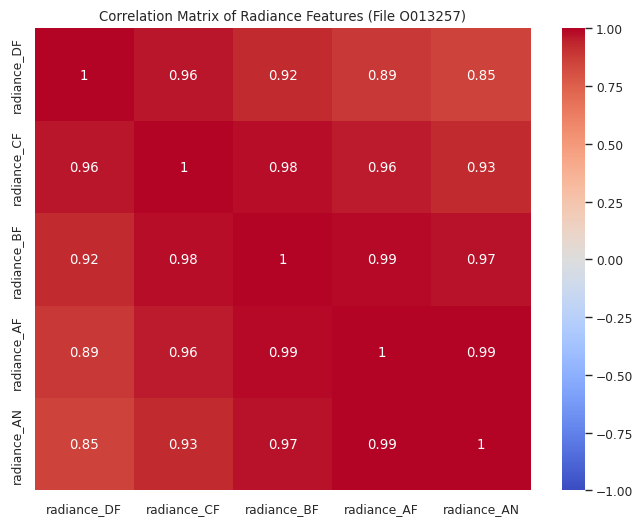

In [20]:
# overall correlation between the radiance features
radiance_cols = ['radiance_DF', 'radiance_CF', 'radiance_BF', 'radiance_AF', 'radiance_AN']
corr_matrix = df1[radiance_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Radiance Features (File O013257)')
plt.show()

**Remark:**

Unsurprisingly, the correlation between different angles are very high (overall, all above 0.85).

Closer the angles are to each other, the highly correlation they have.

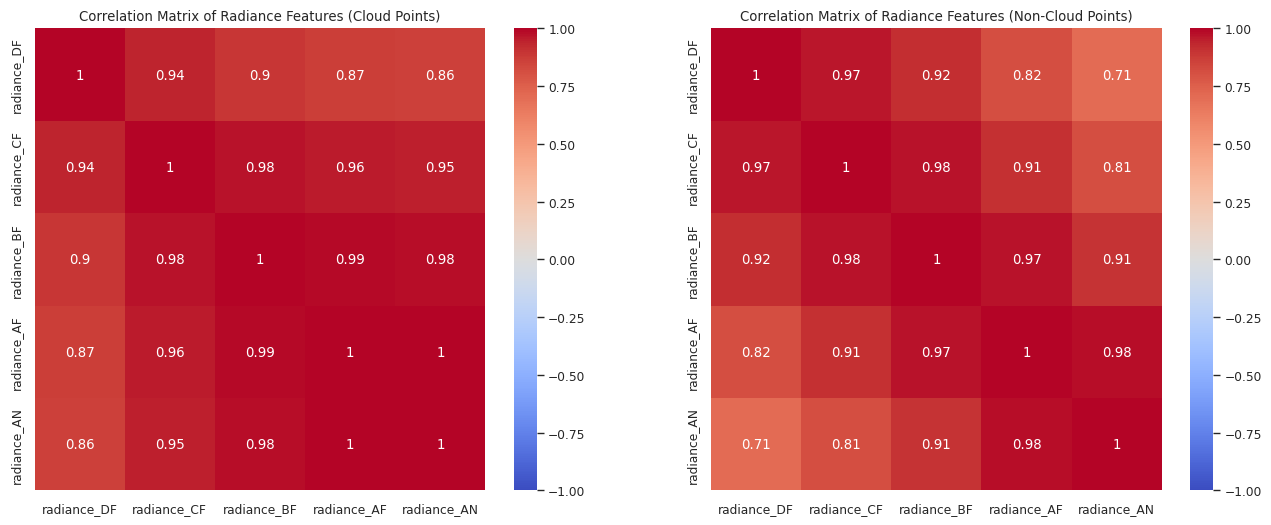

In [21]:
# the correlation matrix for cloud and non-cloud points
corr_cloud = df1[df1['label'] == 1][radiance_cols].corr()
corr_non_cloud = df1[df1['label'] == -1][radiance_cols].corr()
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(corr_cloud, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Radiance Features (Cloud Points)')
plt.subplot(1, 2, 2)
sns.heatmap(corr_non_cloud, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Radiance Features (Non-Cloud Points)')
plt.show()

In [22]:
# summarize the correlation patterns for reporting
from itertools import combinations

# radiance features
rad_cols = ['radiance_DF','radiance_CF','radiance_BF','radiance_AF','radiance_AN']

# split dataset
cloud_df = df1[df1['label'] == 1]
nocloud_df = df1[df1['label'] == -1]
rows = []

for f1, f2 in combinations(rad_cols, 2):

    cloud_corr = cloud_df[[f1, f2]].corr().iloc[0,1]
    nocloud_corr = nocloud_df[[f1, f2]].corr().iloc[0,1]

    rows.append({
        "Feature Pair": f"{f1} – {f2}",
        "Cloud Corr": cloud_corr,
        "Non-Cloud Corr": nocloud_corr,
        "Difference (Cloud − NonCloud)": cloud_corr - nocloud_corr
    })

corr_table = pd.DataFrame(rows)

# round for readability
corr_table = corr_table.round(3)

corr_table

,Feature Pair,Cloud Corr,Non-Cloud Corr,Difference (Cloud − NonCloud)
0,radiance_DF – radiance_CF,0.940,0.966,-0.025
1,radiance_DF – radiance_BF,0.898,0.916,-0.018
2,radiance_DF – radiance_AF,0.871,0.820,0.051
3,radiance_DF – radiance_AN,0.860,0.705,0.155
4,radiance_CF – radiance_BF,0.976,0.975,0.000
5,radiance_CF – radiance_AF,0.959,0.906,0.053
6,radiance_CF – radiance_AN,0.948,0.813,0.136
7,radiance_BF – radiance_AF,0.991,0.971,0.020
8,radiance_BF – radiance_AN,0.983,0.905,0.077
9,radiance_AF – radiance_AN,0.995,0.978,0.017


In [23]:
corr_table.to_latex(
    "../report/radiance_correlation_table.tex",
    index=False,
    float_format="%.3f"
)

In [24]:
def mean_corr(df, cols):
    corr = df1[cols].corr().values
    return corr[np.triu_indices_from(corr,1)].mean()

mean_cloud = mean_corr(cloud_df, rad_cols)
mean_nocloud = mean_corr(nocloud_df, rad_cols)

print("Mean Cloud Correlation:", round(mean_cloud,4))
print("Mean Non-Cloud Correlation:", round(mean_nocloud,4))

Mean Cloud Correlation: 0.9446
Mean Non-Cloud Correlation: 0.9446


**Remark:**

Conditional on the class, we can see that cloud points generally have slightly higher pair correlations between angles compared with non-cloud points. 

More extremely, in image O013257, the corrleation between randiance from AF and that from AN is exactly 1.

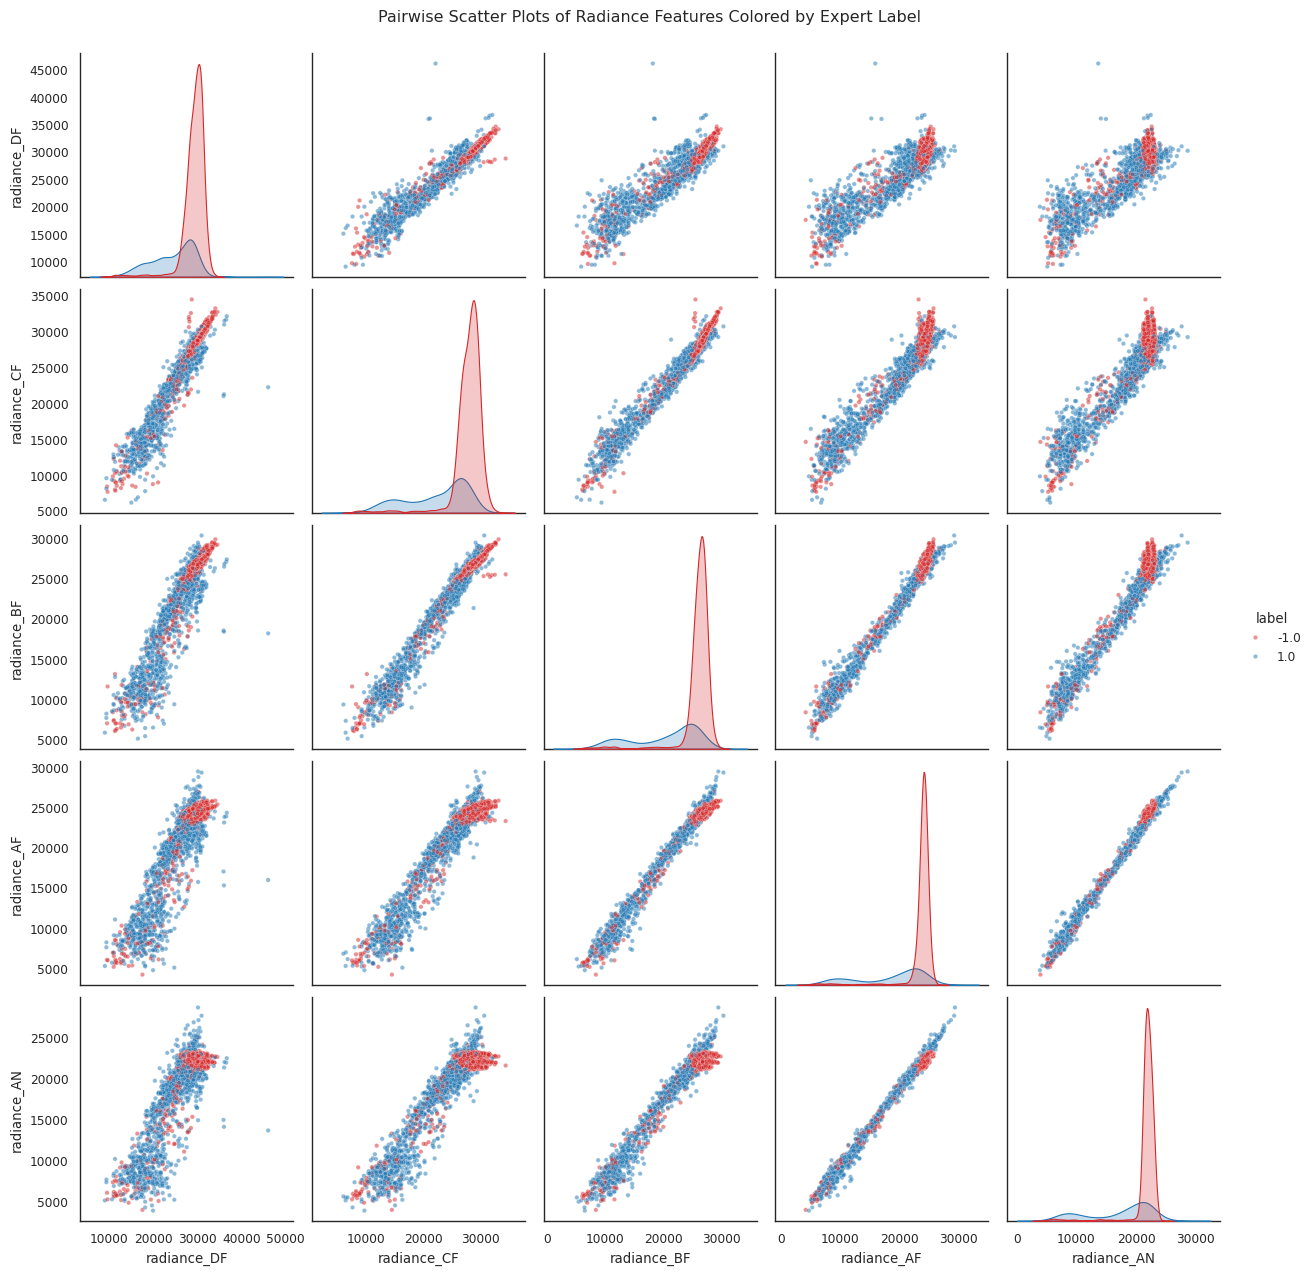

In [25]:
# pairwise scatter plots of the radiance features colored by label
sns.pairplot(df1.query('label != 0').sample(n=5000), 
             vars=radiance_cols, 
             hue='label', 
             palette={-1: '#d62728', 1: '#1f77b4'}, 
             plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Pairwise Scatter Plots of Radiance Features Colored by Expert Label', y=1.02)
plt.show()

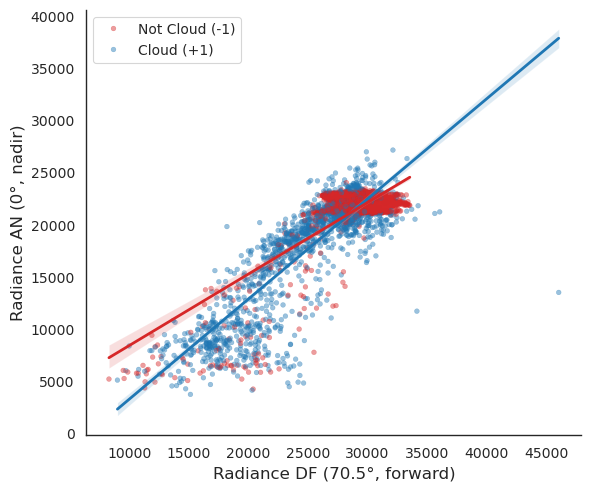

In [26]:
# pairwise plot for one representative feature pair (radiance_DF vs radiance_AN)

# --- Style ---
sns.set_theme(style="white", context="paper")

plt.figure(figsize=(6, 5))

# sample for readability
plot_df = df1.query('label != 0').sample(n=5000, random_state=42)

# map numeric labels to display names so legend text is stable
label_map = {-1: "Not Cloud (-1)", 1: "Cloud (+1)"}
plot_df["label_name"] = plot_df["label"].map(label_map)

ax = sns.scatterplot(
    data=plot_df,
    x="radiance_DF",
    y="radiance_AN",
    hue="label_name",
    hue_order=["Not Cloud (-1)", "Cloud (+1)"],
    palette={"Not Cloud (-1)": "#d62728", "Cloud (+1)": "#1f77b4"},
    alpha=0.45,
    s=12,
    edgecolor=None
)

sns.regplot(
    data=plot_df[plot_df.label == 1],
    x="radiance_DF",
    y="radiance_AN",
    scatter=False,
    color="#1f77b4",
    line_kws={"linewidth": 2}
)

sns.regplot(
    data=plot_df[plot_df.label == -1],
    x="radiance_DF",
    y="radiance_AN",
    scatter=False,
    color="#d62728",
    line_kws={"linewidth": 2}
)

# Set axis labels after all plotting calls to ensure custom labels are retained
ax.set_xlabel("Radiance DF (70.5°, forward)", fontsize=12)
ax.set_ylabel("Radiance AN (0°, nadir)", fontsize=12)
ax.tick_params(axis='both', labelsize=10)
ax.legend( frameon=True, fontsize=10, title_fontsize=11)

# --- Remove top/right borders ---
sns.despine()

plt.tight_layout()
plt.savefig("../figs/radiance_DF_vs_AN_scatter", dpi=300)
plt.show()

In [27]:
# quantify the variation 

df1.query('label != 0').groupby('label')[radiance_cols].agg(['mean', 'std']).round(2)

radiance_DF          radiance_CF          radiance_BF           \
             mean      std        mean      std        mean      std   
label                                                                  
-1.0     29250.25  2425.63    27820.90  2645.41    25913.44  2565.88   
 1.0     24539.20  4837.47    22373.69  5453.88    20344.62  5788.11   

      radiance_AF          radiance_AN           
             mean      std        mean      std  
label                                            
-1.0     23690.85  2363.08    21668.98  2139.95  
 1.0     18583.60  5764.71    17307.12  5484.25

**Remark:**

+ Both from the diagonals and the pairwise scatterplot, we can find that non-cloud point usually shows higher radiance than cloud

+ Radiance of non-cloud points has less variacnce compared with those of cloud ones. 

+ When the two angles are closer, the points are more concentrated, showing higher correlation.



In [28]:
# angular difference inspired by NDAI
# we have ten pairs of radiance features, we can compute the difference between each pair as a new feature, which may capture some angular relationships between the radiance measurements
df1_angular_diff = df1.copy()

for i in range(len(radiance_cols)):
    for j in range(i + 1, len(radiance_cols)):
        col_i = radiance_cols[i]
        col_j = radiance_cols[j]
        new_col_name = f'{col_i[-2:]}_minus_{col_j[-2:]}' # last two characters from the column name to indicate it's a difference
        df1_angular_diff[new_col_name] = df1[col_i] - df1[col_j]

In [29]:
df1_angular_diff.head()

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,...,DF_minus_CF,DF_minus_BF,DF_minus_AF,DF_minus_AN,CF_minus_BF,CF_minus_AF,CF_minus_AN,BF_minus_AF,BF_minus_AN,AF_minus_AN
0,2.0,70.0,0.528076,1820.998779,0.900904,22692.50,19834.00,11228.50,8536.50,7008.25,...,2858.50,11464.00,14156.00,15684.25,8605.50,11297.50,12825.75,2692.0,4220.25,1528.25
1,2.0,71.0,0.593831,1169.416504,0.473416,23461.00,18388.50,11575.25,8993.25,5978.75,...,5072.50,11885.75,14467.75,17482.25,6813.25,9395.25,12409.75,2582.0,5596.50,3014.50
2,2.0,72.0,0.550953,1376.460571,0.861363,23831.75,16752.50,12560.25,9570.75,6900.00,...,7079.25,11271.50,14261.00,16931.75,4192.25,7181.75,9852.50,2989.5,5660.25,2670.75
3,2.0,73.0,0.550160,1389.984863,0.687417,23185.75,15590.75,14639.50,8372.50,6728.25,...,7595.00,8546.25,14813.25,16457.50,951.25,7218.25,8862.50,6267.0,7911.25,1644.25
4,2.0,74.0,0.615813,1388.641357,0.486022,23047.75,16095.25,12771.50,7136.00,5480.00,...,6952.50,10276.25,15911.75,17567.75,3323.75,8959.25,10615.25,5635.5,7291.50,1656.00


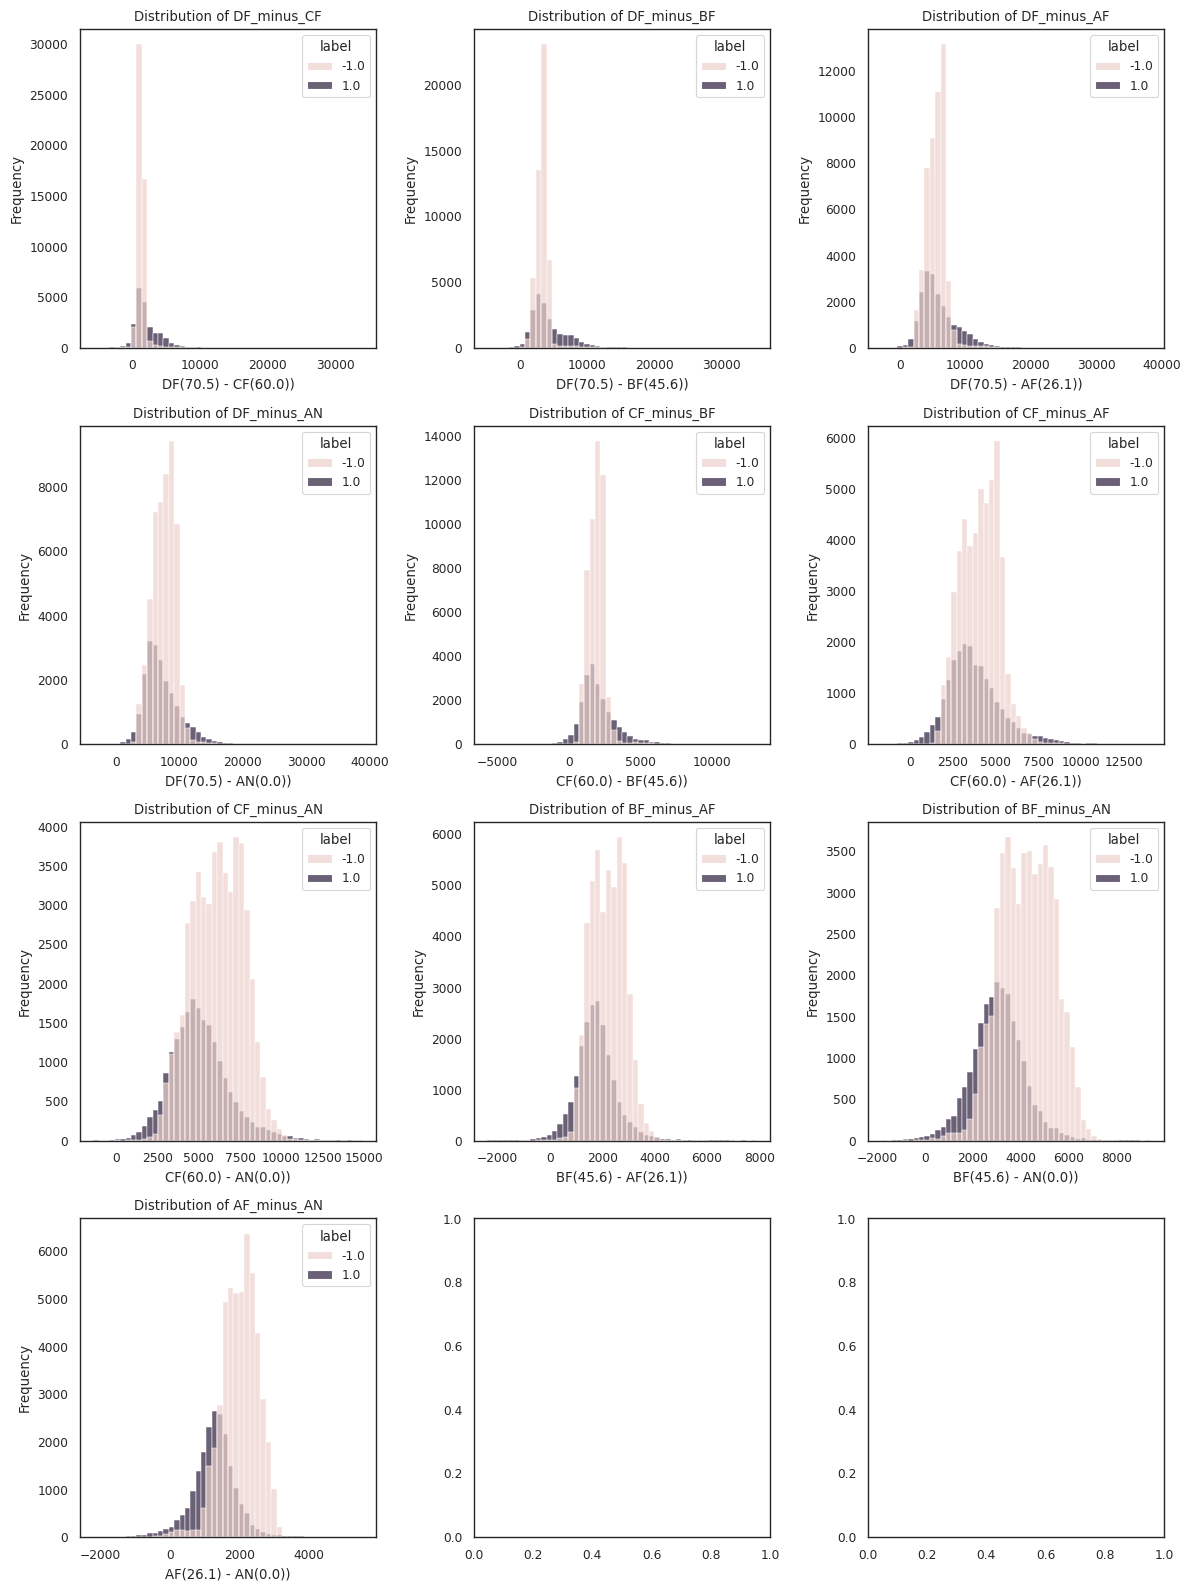

In [30]:
# 4 x 3 hist plots of the angular difference features colored by label
angular_diff_cols = [col for col in df1_angular_diff.columns if '_minus_' in col]
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
axes = axes.flatten()

x_label_map = {
    'DF_minus_CF': 'DF(70.5) - CF(60.0))',
    'DF_minus_BF': 'DF(70.5) - BF(45.6))',
    'DF_minus_AF': 'DF(70.5) - AF(26.1))',
    'DF_minus_AN': 'DF(70.5) - AN(0.0))',
    'CF_minus_BF': 'CF(60.0) - BF(45.6))',
    'CF_minus_AF': 'CF(60.0) - AF(26.1))',
    'CF_minus_AN': 'CF(60.0) - AN(0.0))',
    'BF_minus_AF': 'BF(45.6) - AF(26.1))',
    'BF_minus_AN': 'BF(45.6) - AN(0.0))',
    'AF_minus_AN': 'AF(26.1) - AN(0.0))'
}
for i, col in enumerate(angular_diff_cols):
        filtered_df = df1_angular_diff.query('label != 0')
        sns.histplot(data=filtered_df, x=col, hue='label', bins=50, alpha=0.7, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(x_label_map.get(col, col))
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Remark:**

I plot the distribution of difference between radiances from different angles. 

Two observations:

+ when angles are closer, their differences are more concentrated which means show less variation
+ between cloud and non-cloud points, cloud points have more variation in the radiance difference, showing heavier tails

#### 2. Relationships between label and radiances


> Instead of using Pearson correlation, which is usually used between continuous variables, I use Point-Biserial Correlation to explore the relationships
> The conclusion changes: Instead of low correlation, exactly for radiance from all 5 angles, we have **significantly negative** correlation between radiance and label with p-value close to 0. It means higher radiances are associated with non-cloud.

In [31]:
# instead of using pearson correlation, we can use Point-Biserial Correlation
# we test the correlation only using labeled data
from scipy.stats import pointbiserialr
for col in radiance_cols:
    corr, p_value = pointbiserialr(df1.query('label != 0')[col], df1.query('label != 0')['label'])
    print(f"Point-Biserial Correlation between {col} and label: {corr:.4f} (p-value: {p_value:.4e})")

Point-Biserial Correlation between radiance_DF and label: -0.5423 (p-value: 0.0000e+00)
Point-Biserial Correlation between radiance_CF and label: -0.5568 (p-value: 0.0000e+00)
Point-Biserial Correlation between radiance_BF and label: -0.5544 (p-value: 0.0000e+00)
Point-Biserial Correlation between radiance_AF and label: -0.5321 (p-value: 0.0000e+00)
Point-Biserial Correlation between radiance_AN and label: -0.4965 (p-value: 0.0000e+00)


### B: Three expert features

Based on our previous exploration and , we already have basic knowledge of the radiances.

+ Correlation: cloud points have less correlation between different angles
+ Variation: cloud points have more variance in radiance
+ NDAI: the radiance difference between different angles tends to be larger in absolute value.

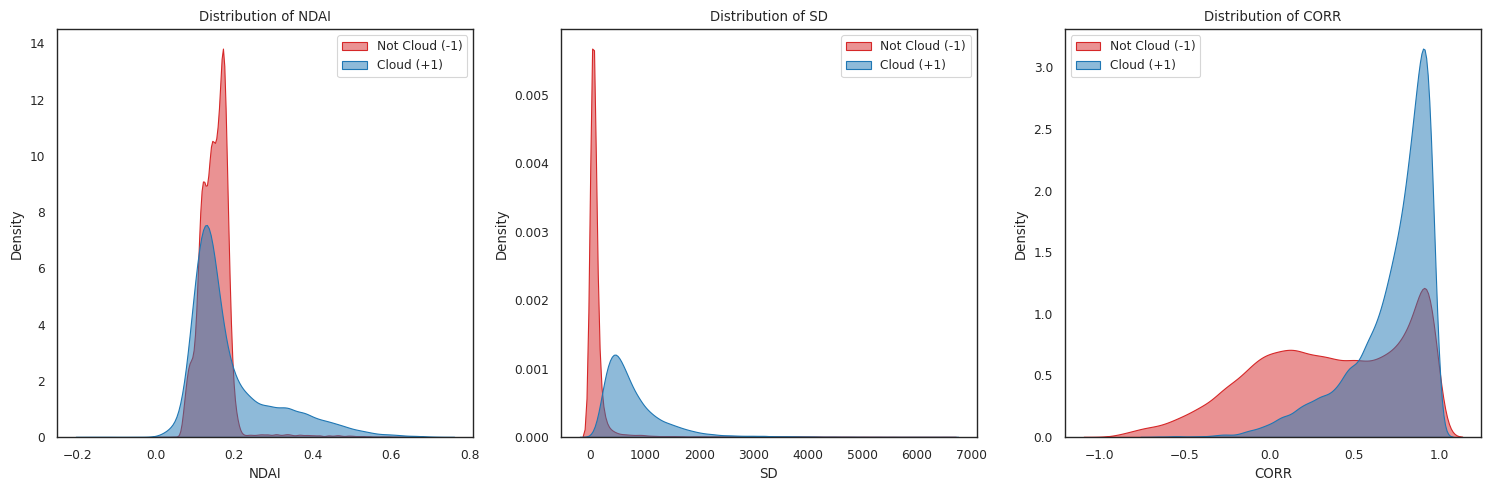

In [32]:
# KDE plots for three expert features colored by label
expert_feature_cols = ['NDAI', 'SD', 'CORR']
sns.set_theme(style="white", context="paper")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(expert_feature_cols):
    filtered_df = df1.query('label != 0')
    
    sns.kdeplot(
        data=filtered_df[filtered_df['label'] == -1], 
        x=col, 
        color='#d62728', 
        label='Not Cloud (-1)', 
        fill=True, 
        alpha=0.5, 
        ax=axes[i]
    )
    
    sns.kdeplot(
        data=filtered_df[filtered_df['label'] == 1], 
        x=col, 
        color='#1f77b4', 
        label='Cloud (+1)', 
        fill=True, 
        alpha=0.5, 
        ax=axes[i]
    )
    
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.savefig("../figs/KDE_expert_features", dpi=300)
plt.show()


**Remark**:

The kde plots are consistent with our domain knowlege.

+ `CORR`: **Low** value for high altitude clouds and high values for either clear(cloud-free) conditions or the presence of low altitude cloud

+ `SD`: It has small values for radiation emanating from smooth surfaces over which the correlations between different MISR view directions are dominated by instrument noise.

+ `NDAI`: Over clouds in the arctic region, radiation collected in the Df camera is much higher than that collected in the An camera; thus larger NDAI values suggest the presence of clouds.

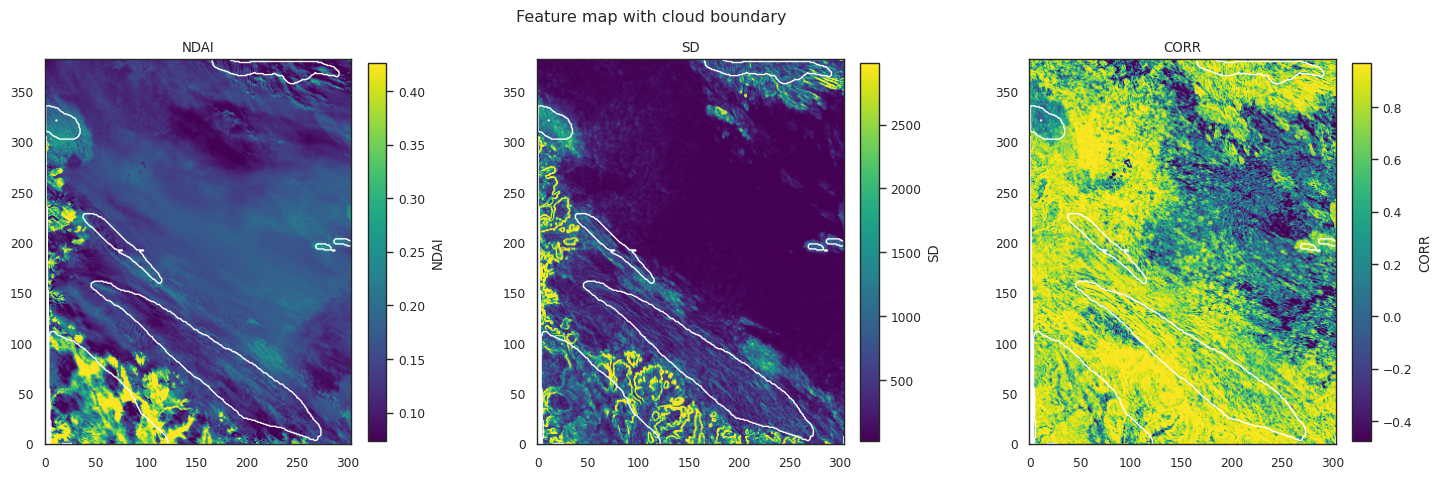

In [33]:
expert_features = ["NDAI", "SD", "CORR"]

# Create label image once
label_img = df1.pivot(
    index="y_coord",
    columns="x_coord",
    values="label"
).values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, expert_features):
    
    feature_img = df1.pivot(
        index="y_coord",
        columns="x_coord",
        values=feature
    ).values
    
    feature_img = np.ma.masked_invalid(feature_img)
    
    # Robust color scaling (avoid extreme outliers)
    vmin = np.percentile(feature_img.compressed(), 2)
    vmax = np.percentile(feature_img.compressed(), 98)
    
    im = ax.imshow(feature_img, cmap="viridis", vmin=vmin, vmax=vmax)
    
    # Overlay cloud boundary
    ax.contour(label_img == 1, levels=[0.5], colors="white", linewidths=1)
    
    ax.set_title(feature)
    ax.invert_yaxis()
    
    # Individual colorbar per subplot
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(feature)

plt.suptitle('Feature map with cloud boundary')
plt.show()

**Remark:**

From the heatmap with cloud boundary, we can see:
+ NADI high inside cloud regions
+ SD high in cloud regions
+ CORR low in cloud regions

But the three qualities don't apply to all the cloud regions simultaneously in the image, which implies the combination of these features can do better prediction.

#### 1. Correlations between features

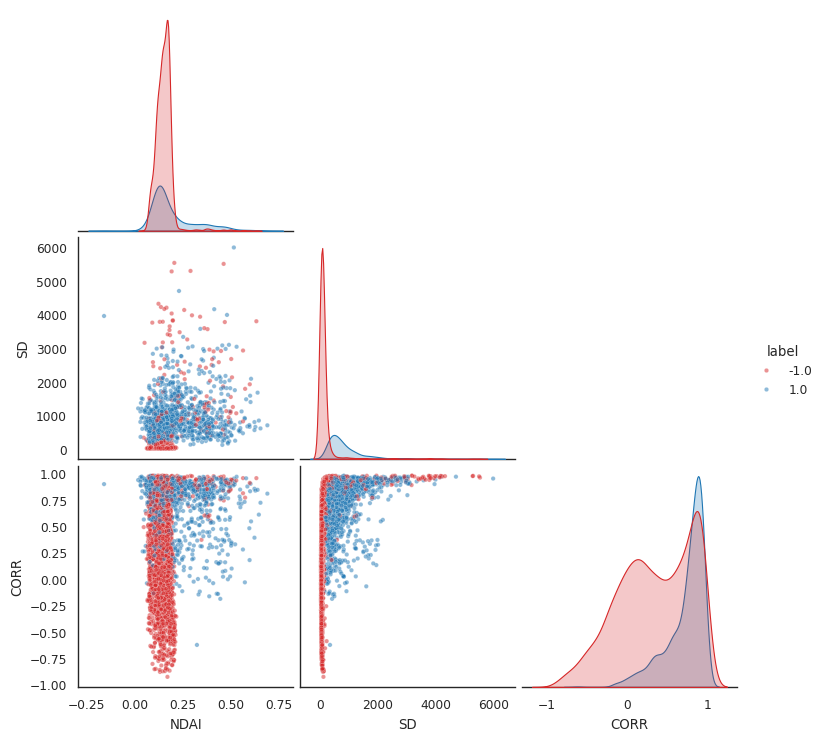

In [34]:
sns.pairplot(
    df1.query('label !=0').sample(5000),
    vars=["NDAI", "SD", "CORR"],
    hue="label",
    corner=True,
    palette={-1: '#d62728', 1: '#1f77b4'}, 
    plot_kws={'alpha': 0.5, 's': 10}
)

In [35]:
df1.groupby("label")[["NDAI", "SD", "CORR"]].corr()

NDAI        SD      CORR
label                                   
-1.0  NDAI  1.000000  0.370546  0.011917
      SD    0.370546  1.000000  0.297092
      CORR  0.011917  0.297092  1.000000
 0.0  NDAI  1.000000  0.310116  0.028621
      SD    0.310116  1.000000  0.412566
      CORR  0.028621  0.412566  1.000000
 1.0  NDAI  1.000000  0.264101 -0.189571
      SD    0.264101  1.000000  0.243154
      CORR -0.189571  0.243154  1.000000

In [36]:
df2.groupby("label")[["NDAI", "SD", "CORR"]].corr()

NDAI        SD      CORR
label                                   
-1.0  NDAI  1.000000  0.569478  0.322393
      SD    0.569478  1.000000  0.421167
      CORR  0.322393  0.421167  1.000000
 0.0  NDAI  1.000000  0.246865  0.021057
      SD    0.246865  1.000000  0.357959
      CORR  0.021057  0.357959  1.000000
 1.0  NDAI  1.000000  0.146651 -0.142752
      SD    0.146651  1.000000  0.269915
      CORR -0.142752  0.269915  1.000000

In [37]:
df3.groupby("label")[["NDAI", "SD", "CORR"]].corr()

NDAI        SD      CORR
label                                   
-1.0  NDAI  1.000000  0.316504  0.143690
      SD    0.316504  1.000000  0.349898
      CORR  0.143690  0.349898  1.000000
 0.0  NDAI  1.000000  0.251806 -0.071631
      SD    0.251806  1.000000  0.161623
      CORR -0.071631  0.161623  1.000000
 1.0  NDAI  1.000000  0.347204 -0.002840
      SD    0.347204  1.000000  0.264346
      CORR -0.002840  0.264346  1.000000

**Remark:**

These three features have relatively low correlation between each other.

From their definitions, their constructions are not simply linear combinations. Theoretically, they should have less linear correlation.

Conditional on cloud class, within cloud points, the correlations tend to be lower. More interestingly, the correlation between `CORR` and `NDAI` becomes negative.

The conclusions hold true for all the three images.

#### 2. Correlations between features and labels

In [38]:
# quantive difference
# try t-test for the mean difference in three features

df1.groupby("label")[["NDAI", "SD", "CORR"]].mean()

,NDAI,SD,CORR
label,,,
-1.0,0.150481,148.910725,0.353443
0.0,0.164405,760.992709,0.670347
1.0,0.191321,794.631870,0.719039


In [39]:
df2.groupby("label")[["NDAI", "SD", "CORR"]].mean()

,NDAI,SD,CORR
label,,,
-1.0,0.150802,138.004932,0.302783
0.0,0.205669,951.530327,0.544374
1.0,0.336912,709.364287,0.198649


In [40]:
df3.groupby("label")[["NDAI", "SD", "CORR"]].mean()

,NDAI,SD,CORR
label,,,
-1.0,0.120715,218.975086,0.467693
0.0,0.185507,993.527337,0.541878
1.0,0.201549,682.006314,0.515465


In [41]:
# t-test for the mean difference in three features between cloud and non-cloud points
# image 1
from scipy.stats import ttest_ind
for col in ["NDAI", "SD", "CORR"]:
    cloud_values = df1[df1['label'] == 1][col]
    non_cloud_values = df1[df1['label'] == -1][col]
    t_stat, p_value = ttest_ind(cloud_values, non_cloud_values, equal_var=False)
    print(f"T-test for {col}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")

T-test for NDAI: t-statistic = 50.8245, p-value = 0.0000e+00
T-test for SD: t-statistic = 140.2436, p-value = 0.0000e+00
T-test for CORR: t-statistic = 139.6435, p-value = 0.0000e+00


In [42]:
# image 2
for col in ["NDAI", "SD", "CORR"]:
    cloud_values = df2[df2['label'] == 1][col]
    non_cloud_values = df2[df2['label'] == -1][col]
    t_stat, p_value = ttest_ind(cloud_values, non_cloud_values, equal_var=False)
    print(f"T-test for {col}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")

T-test for NDAI: t-statistic = 314.9169, p-value = 0.0000e+00
T-test for SD: t-statistic = 213.3311, p-value = 0.0000e+00
T-test for CORR: t-statistic = -40.4488, p-value = 0.0000e+00


In [43]:
# image 3
for col in ["NDAI", "SD", "CORR"]:
    cloud_values = df3[df3['label'] == 1][col]
    non_cloud_values = df3[df3['label'] == -1][col]
    t_stat, p_value = ttest_ind(cloud_values, non_cloud_values, equal_var=False)
    print(f"T-test for {col}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")

T-test for NDAI: t-statistic = 127.2063, p-value = 0.0000e+00
T-test for SD: t-statistic = 88.3435, p-value = 0.0000e+00
T-test for CORR: t-statistic = 14.8531, p-value = 8.7034e-50


In [44]:
# image 1
for col in ["NDAI", "SD", "CORR"]:
    corr, p_value = pointbiserialr(df1.query('label != 0')[col], df1.query('label != 0')['label'])
    print(f"Point-Biserial Correlation between {col} and label: {corr:.4f} (p-value: {p_value:.4e})")

Point-Biserial Correlation between NDAI and label: 0.2524 (p-value: 0.0000e+00)
Point-Biserial Correlation between SD and label: 0.5091 (p-value: 0.0000e+00)
Point-Biserial Correlation between CORR and label: 0.3835 (p-value: 0.0000e+00)


In [45]:
# image 2
for col in ["NDAI", "SD", "CORR"]:
    corr, p_value = pointbiserialr(df2.query('label != 0')[col], df2.query('label != 0')['label'])
    print(f"Point-Biserial Correlation between {col} and label: {corr:.4f} (p-value: {p_value:.4e})")

Point-Biserial Correlation between NDAI and label: 0.7514 (p-value: 0.0000e+00)
Point-Biserial Correlation between SD and label: 0.6005 (p-value: 0.0000e+00)
Point-Biserial Correlation between CORR and label: -0.1382 (p-value: 0.0000e+00)


In [46]:
# image 3
for col in ["NDAI", "SD", "CORR"]:
    corr, p_value = pointbiserialr(df3.query('label != 0')[col], df3.query('label != 0')['label'])
    print(f"Point-Biserial Correlation between {col} and label: {corr:.4f} (p-value: {p_value:.4e})")

Point-Biserial Correlation between NDAI and label: 0.5314 (p-value: 0.0000e+00)
Point-Biserial Correlation between SD and label: 0.3652 (p-value: 0.0000e+00)
Point-Biserial Correlation between CORR and label: 0.0633 (p-value: 1.0799e-49)


**Remark:**

> Based on both T-tests between means and point-biserial correlation, we can say the differences between classes in the three features are all significant (or the features have significant correlation with cloud label).
> However, in images (O013257.npz and O012791.npz), the mean of `CORR` in cloud group is **higher** than that in non-cloud group, which is **counterintuitive**. The point-biserial correlation is also **significantly positive**. It implies the `CORR` variable alone is not supportive and stable for classification.
> In fact, the paper has also stated this situation: "High values of CORR suggest either clear (cloud-free) conditions or the presence of low altitude cloud that is registered to the same location on the underlying surface. But if we declare clear for high CORR pixels and cloudy for low CORR ones, then we can produce two types of errors: Smooth cloud-free terrain surfaces can be classified as cloudy (low signal-to-noise ratios lead to low correlations), and low altitude clouds can be classified as clear."

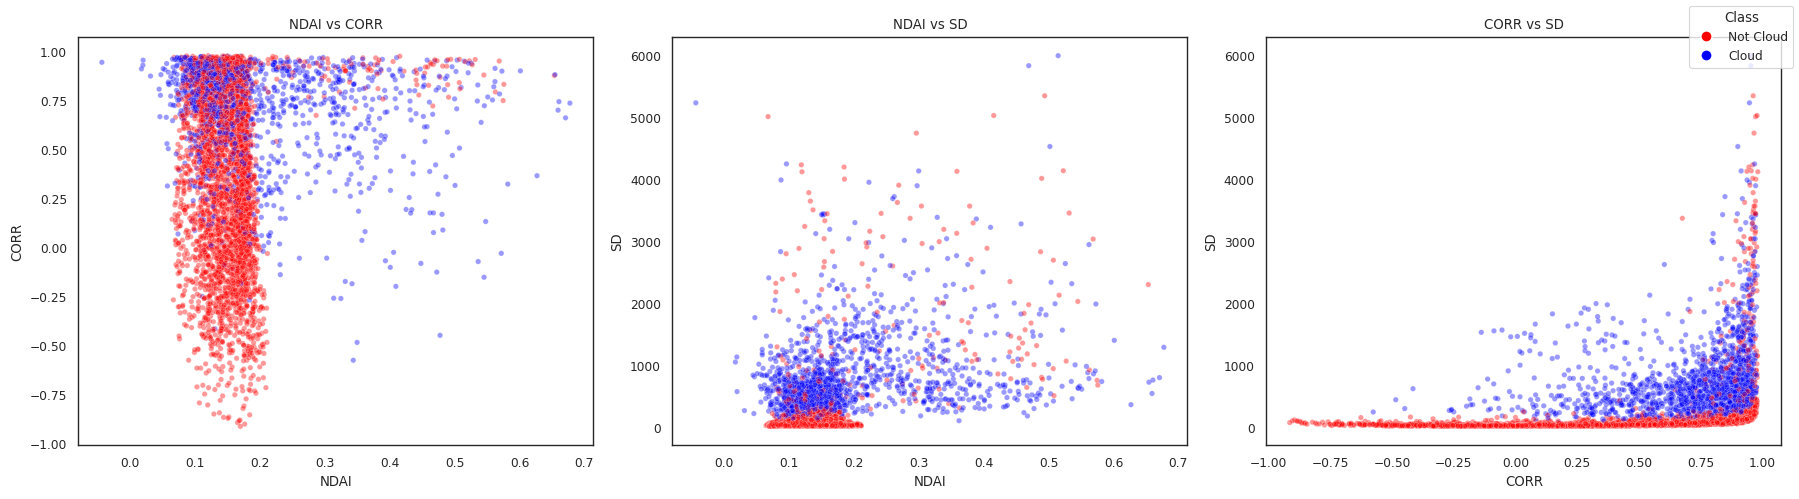

In [47]:
# Labeled only
df_labeled = df1.query("label != 0")
df_plot = df_labeled.sample(5000, random_state=42)

pairs = [
    ("NDAI", "CORR"),
    ("NDAI", "SD"),
    ("CORR", "SD")
]

# Define color mapping
palette = {
    -1: "red",   # not cloud
    1: "blue"    # cloud
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x_feat, y_feat) in zip(axes, pairs):
    sns.scatterplot(
        data=df_plot,
        x=x_feat,
        y=y_feat,
        hue="label",
        palette=palette,
        alpha=0.4,
        s=15,
        ax=ax,
        legend=False  # suppress individual legends
    )
    ax.set_title(f"{x_feat} vs {y_feat}")

# Create a single shared legend

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Not Cloud',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Cloud',
           markerfacecolor='blue', markersize=8)
]

fig.legend(handles=legend_elements, loc="upper right", title="Class")

plt.tight_layout()
plt.show()

**Remark:**

Based on the three pairplots, it looks like `SD` and `NDAI` are decisive for cloud classification while `CORR` show relatively uniform distribution in two classes.

## Step 5: Splitting

As for the data splitting, use simple random split seems risky. 

Since pixels that are close in (x,y) are highly correlated, have similar radiance and share cloud structure. Random splitting is easy to get artificially high performance, where we run into **spatial leakage**.

There are several options for better splitting:

**Option 1: split by image**

+ Train: Image 1
+ Val: Image 2
+ Test: Image 3

Since pixels within an image are spatially correlated, we split at the image level to avoid leakage and better simulate deployment on unseen satellite images.

This is not common data splitting strategy. Image-level splitting gives very small training diversity and images may have distribution shift. This leads to the concern of high variance.

---

**Option 2: split by blocks**

Divide each image into spatial regions, then split the data based on the blocks. 


+ divid two images into $n \times n$ blocks and split them to train and val splits
+ the remaining whole image as the test sets.


This preserves spatial independence better than random split.


> The image-based strategy is the same thing as group-based.

> Based on our analysis, block-level split has the risk of data leakage due to our existing feature aggregating the information from neighourhood pixels. At least, the units on the boundaries of the block has the spatial data leakage.

In [48]:
# the label distribution in the three files
df1.query("label != 0")['label'].value_counts(normalize=True)

label
-1.0    0.71101
 1.0    0.28899
Name: proportion, dtype: float64

In [49]:
df2.query("label != 0")['label'].value_counts(normalize=True)

label
-1.0    0.521789
 1.0    0.478211
Name: proportion, dtype: float64

In [50]:
df3.query("label != 0")['label'].value_counts(normalize=True)

label
-1.0    0.612138
 1.0    0.387862
Name: proportion, dtype: float64

The distributions of labels in different images vary.

### Block-based splitting

In [51]:
n_bins = 3

df1["x_bin"] = pd.qcut(df1["x_coord"], n_bins, labels=False)
df1["y_bin"] = pd.qcut(df1["y_coord"], n_bins, labels=False)

df1["block"] = df1["x_bin"] + n_bins * df1["y_bin"]

In [52]:
df1['block'].value_counts()

block
6    12939
3    12924
1    12800
4    12800
5    12800
2    12792
0    12745
7    12600
8    12600
Name: count, dtype: int64

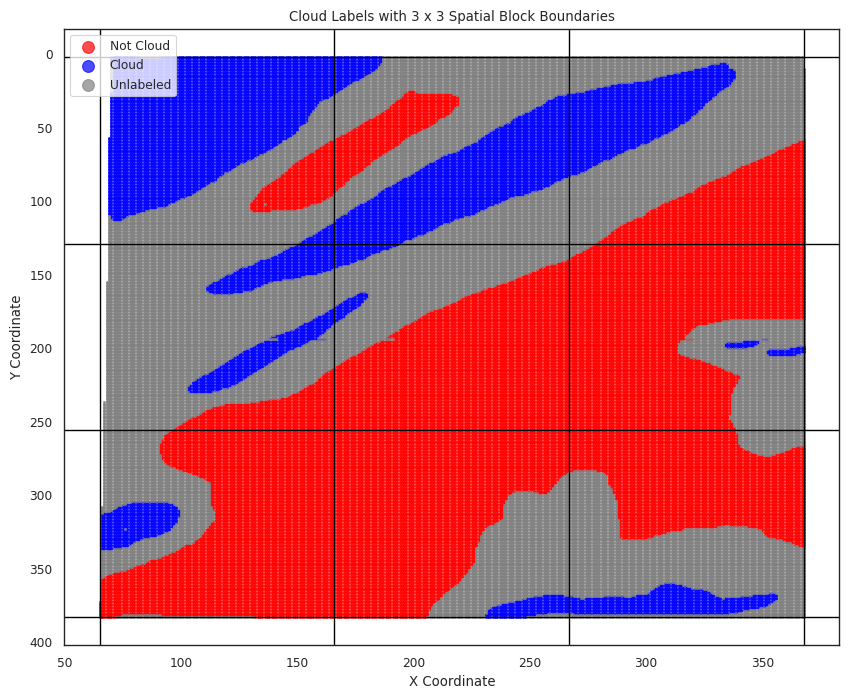

In [53]:
x_bins = np.linspace(df1['x_coord'].min(), df1['x_coord'].max(), n_bins+1)
y_bins = np.linspace(df1['y_coord'].min(), df1['y_coord'].max(), n_bins+1)

plt.figure(figsize=(10, 8))

# Plot cloud labels
plt.scatter(
    df1.loc[df1['label']==-1, 'x_coord'],
    df1.loc[df1['label']==-1, 'y_coord'],
    color='red', s = 2, label='Not Cloud', alpha=0.7
)

plt.scatter(
    df1.loc[df1['label']==1, 'x_coord'],
    df1.loc[df1['label']==1, 'y_coord'],
    color='blue', s=2, label='Cloud',alpha=0.7
)

plt.scatter(
    df1.loc[df1['label']==0, 'x_coord'],
    df1.loc[df1['label']==0, 'y_coord'],
    color='grey', s=2, label='Unlabeled',alpha=0.7
)


# Draw vertical grid lines
for xb in x_bins:
    plt.axvline(x=xb, color='black', linewidth=1)

# Draw horizontal grid lines
for yb in y_bins:
    plt.axhline(y=yb, color='black', linewidth=1)

plt.gca().invert_yaxis()
plt.title('Cloud Labels with {} x {} Spatial Block Boundaries'.format(n_bins, n_bins))
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend(markerscale=6)

plt.show()

In [54]:

def add_block_ids(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    Add n×n spatial block ids based on x/y coordinate bins.
    Returns a copy of df with columns: x_bin, y_bin, block_id.
    """
    out = df.copy()

    # Create evenly spaced bins across coordinate range
    x_bins = np.linspace(out["x_coord"].min(), out["x_coord"].max(), n + 1)
    y_bins = np.linspace(out["y_coord"].min(), out["y_coord"].max(), n + 1)

    # Assign each point to a bin [0, n-1]
    out["x_bin"] = np.clip(np.digitize(out["x_coord"], x_bins) - 1, 0, n - 1)
    out["y_bin"] = np.clip(np.digitize(out["y_coord"], y_bins) - 1, 0, n - 1)

    # Unique block id in [0, n*n-1]
    out["block_id"] = out["x_bin"] + n * out["y_bin"]
    return out


def block_split_images(
    df_all: pd.DataFrame,
    image_col: str,
    image_ids: list,
    n_blocks: int = 3,
    val_frac: float = 0.2,
    random_state: int = 42,
):
    """
    Strategy:
      - Use `train_val_df` (two images) for train/val via n×n spatial block split
      - Use `test_df` as an entire held-out test set
      - Split is done at BLOCK level to reduce spatial leakage.
    """
    rng = np.random.default_rng(random_state)


    # --- subset images ---
    df_tv = df_all[df_all[image_col].isin(image_ids)].copy()

    # --- add blocks per image (bins are computed within each image) ---
    df_tv_blocks = []
    for img_id, g in df_tv.groupby(image_col, sort=False):
        g2 = add_block_ids(g, n_blocks)
        # Make block ids unique across images (so we split blocks within each image consistently)
        g2["global_block"] = g2[image_col].astype(str) + "_b" + g2["block_id"].astype(str)
        df_tv_blocks.append(g2)
    df_tv = pd.concat(df_tv_blocks, ignore_index=True)
    # --- choose validation blocks (within the union of two images) ---
    all_blocks = df_tv["global_block"].unique()
    n_val_blocks = max(1, int(np.round(val_frac * len(all_blocks))))
    val_blocks = set(rng.choice(all_blocks, size=n_val_blocks, replace=False))

    # --- split ---
    val_df = df_tv[df_tv["global_block"].isin(val_blocks)].copy()
    train_df = df_tv[~df_tv["global_block"].isin(val_blocks)].copy()


    return train_df, val_df

In [55]:
image_col = "image_id"
df1[image_col] = "O013257"
df2[image_col] = "O013490"
df3[image_col] = "O012791"
df_all = pd.concat([df1, df2, df3], ignore_index=True)

In [56]:
train_df, val_df = block_split_images(
    df_all=df_all,
    image_col=image_col,
    image_ids=["O013257", "O012791"],
    n_blocks=3,
    val_frac=0.2,
    random_state=42
)
print("Train set shape:", train_df.shape)
print("Train label distribution:\n", train_df['label'].value_counts(normalize=True))
print("Val set shape:", val_df.shape)
print("Val label distribution:\n", val_df['label'].value_counts(normalize=True))

Train set shape: (178839, 17)
Train label distribution:
 label
 0.0    0.468628
-1.0    0.350869
 1.0    0.180503
Name: proportion, dtype: float64
Val set shape: (51134, 17)
Val label distribution:
 label
-1.0    0.413365
 0.0    0.402198
 1.0    0.184437
Name: proportion, dtype: float64


In [57]:
train_df.head()

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,label,x_bin,y_bin,block,image_id,block_id,global_block
0,2.0,70.0,0.528076,1820.998779,0.900904,22692.50,19834.00,11228.50,8536.50,7008.25,0.0,0,0,0.0,O013257,0,O013257_b0
1,2.0,71.0,0.593831,1169.416504,0.473416,23461.00,18388.50,11575.25,8993.25,5978.75,1.0,0,0,0.0,O013257,0,O013257_b0
2,2.0,72.0,0.550953,1376.460571,0.861363,23831.75,16752.50,12560.25,9570.75,6900.00,1.0,0,0,0.0,O013257,0,O013257_b0
3,2.0,73.0,0.550160,1389.984863,0.687417,23185.75,15590.75,14639.50,8372.50,6728.25,1.0,0,0,0.0,O013257,0,O013257_b0
4,2.0,74.0,0.615813,1388.641357,0.486022,23047.75,16095.25,12771.50,7136.00,5480.00,1.0,0,0,0.0,O013257,0,O013257_b0


In this case, train and val data have more columns for block than orginial data.

### Prepare data function

1. spliting strategy: image based | block based
  
2. standardization: z-score |  median/IQR
   + our basic exploration has told us the scales of different features vary a lot. For stability, it's better to standardized them.


> Add the removing outlier option
> get the outlier from train data and apply that in val and test



> Remove the block split option

In [58]:
# prepare funtion with the splitting judgment calls
from sklearn.preprocessing import StandardScaler, RobustScaler
def prepare_data(
    filepaths: list,
    feature_cols: list,
    coord_cols: list = ["y_coord", "x_coord"],
    image_col: str = "image_id",
    label_col: str = "label",
    train_images: list | None = None,
    val_images: list | None = None,
    test_images: list | None = None,
    # ---- common
    labeled_only: bool = True,
    map_label_to_binary: bool = False,
    # ---- scaling 
    scale: bool = False,
    scaler_type: str | None = None,  # "standard", "robust", or None,
    scaler_feature_cols: list | None = None,  # columns to scale (if None, use feature_cols
    # ---- remove outliers 
    remove_outliers: bool = False,
    outlier_threshold: float = 3.0,  # Z-score threshold for outlier removal
    outlier_cols: list | None = None,  # columns to check for outliers (if None, use feature_cols
):
    """Prepares train/val/test dataframes from raw .npz files with various preprocessing options.
    Steps:
    1. Load and concatenate data from all filepaths, adding an image ID column.
    2. Subset to specified images for train/val/test splits.
    3. Optionally remove outliers based on Z-score within the training set (fit on train, apply to val/test).
    4. Optionally scale features using StandardScaler or RobustScaler (fit on train, apply to val/test).
    5. Optionally filter to only labeled data (label != 0).
    6. Optionally map labels to binary (e.g., 1 -> 1 for cloud, -1 -> 0 for not cloud).
    Returns:
    - train_df: DataFrame for training
    - val_df: DataFrame for validation
    - test_df: DataFrame for testing
    """
    
    # Load and concatenate data
    dfs = []
    for filepath in filepaths:
        df = clean(filepath)
        df[image_col] = os.path.basename(filepath).split('.')[0]  # Extract image ID from filename
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    # Subset to specified images for train/val/test
    train_df = df_all[df_all[image_col].isin(train_images)].copy()
    val_df = df_all[df_all[image_col].isin(val_images)].copy()
    test_df = df_all[df_all[image_col].isin(test_images)].copy()
    
    # palceholder for new features
    # merge key: image_id, x_coord, y_coord


    # remove outliers based on Z-score within the training set (fit on train, apply to val/test)
    if remove_outliers:
        if outlier_cols is None:
            outlier_cols = feature_cols
        # Compute Z-scores based on training set
        train_stats = train_df[outlier_cols].agg(['mean', 'std'])
        z_scores_train = (train_df[outlier_cols] - train_stats.loc['mean']) / train_stats.loc['std']
        z_scores_val = (val_df[outlier_cols] - train_stats.loc['mean']) / train_stats.loc['std']
        z_scores_test = (test_df[outlier_cols] - train_stats.loc['mean']) / train_stats.loc['std']

        # Keep only rows where all specified columns have Z-score within the threshold
        train_df = train_df[(z_scores_train.abs() <= outlier_threshold).all(axis=1)].copy()
        val_df = val_df[(z_scores_val.abs() <= outlier_threshold).all(axis=1)].copy()
        test_df = test_df[(z_scores_test.abs() <= outlier_threshold).all(axis=1)].copy()

    # Scaling (fit on train, apply to val/test)
    if scale and scaler_type is not None:
        if scaler_type == "standard":
            scaler = StandardScaler()
        elif scaler_type == "robust":
            scaler = RobustScaler()
        else:
            raise ValueError("scaler_type must be 'standard', 'robust', or None")

        train_df[scaler_feature_cols] = scaler.fit_transform(train_df[scaler_feature_cols])
        val_df[scaler_feature_cols] = scaler.transform(val_df[scaler_feature_cols])
        test_df[scaler_feature_cols] = scaler.transform(test_df[scaler_feature_cols])
        
    # Drop unlabeled AFTER split
    if labeled_only:
        train_df = train_df[train_df[label_col] != 0].copy()
        val_df = val_df[val_df[label_col] != 0].copy()
        test_df = test_df[test_df[label_col] != 0].copy()


    # Optional: map to binary labels
    if map_label_to_binary:
        # 1 -> 1 (cloud), -1 -> 0 (not cloud)
        for df in (train_df, val_df, test_df):
            df[label_col] = (df[label_col] == 1).astype(int)

    return (
        train_df, val_df, test_df,
    )

In [59]:
# example usage

train_df, val_df,test_df = prepare_data(
    filepaths=["../data/O012791.npz", "../data/O013257.npz", "../data/O013490.npz"],
    feature_cols=["NDAI","SD","CORR","radiance_DF","radiance_CF","radiance_BF","radiance_AF","radiance_AN"],
    coord_cols=["y_coord", "x_coord"],
    image_col="image_id",
    label_col="label",
    train_images=["O012791"],
    val_images=["O013257"],
    test_images=["O013490"],
    labeled_only=True,
    map_label_to_binary=True,
    scale = False,
    scaler_type = None,
    scaler_feature_cols = None,
    remove_outliers = False,
    outlier_threshold = 3.0,
    outlier_cols = None
    
)
print("Train set shape:", train_df.shape)
print("Train label distribution:\n", train_df['label'].value_counts(normalize=True))
print("Val set shape:", val_df.shape)
print("Val label distribution:\n", val_df['label'].value_counts(normalize=True))
print("Test set shape:", test_df.shape)
print("Test label distribution:\n", test_df['label'].value_counts(normalize=True))

Train set shape: (54772, 12)
Train label distribution:
 label
0    0.612138
1    0.387862
Name: proportion, dtype: float64
Val set shape: (70826, 12)
Val label distribution:
 label
0    0.71101
1    0.28899
Name: proportion, dtype: float64
Test set shape: (82083, 12)
Test label distribution:
 label
0    0.521789
1    0.478211
Name: proportion, dtype: float64


In [60]:
test_df.head()

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,label,image_id
229973,2.0,70.0,0.464717,559.852661,0.102706,30504.75,24295.25,17605.50,13117.00,11148.00,1,O013490
229974,2.0,71.0,0.456528,793.804260,0.123094,30439.25,23639.75,17616.00,13459.50,11357.75,1,O013490
229975,2.0,72.0,0.458067,688.978333,0.159742,30303.00,23672.25,17756.25,12827.50,11263.00,1,O013490
229976,2.0,73.0,0.455218,431.706848,0.109461,30736.75,24212.25,17774.75,13153.25,11506.75,1,O013490
229977,2.0,74.0,0.460866,420.481476,0.030519,30634.00,23867.50,17453.75,13429.25,11305.50,1,O013490


In [61]:
# remove outliers and use standard scaling
train_df, val_df,test_df = prepare_data(
    filepaths=["../data/O012791.npz", "../data/O013257.npz", "../data/O013490.npz"],
    feature_cols=["NDAI","SD","CORR","radiance_DF","radiance_CF","radiance_BF","radiance_AF","radiance_AN"],
    coord_cols= ['x_coord','y_coord'],
    image_col="image_id",
    label_col="label",
    train_images=["O013257"],
    val_images=["O012791"],
    test_images=["O013490"],
    labeled_only=True,
    map_label_to_binary=True,
    remove_outliers=True,       
    outlier_threshold=3.0,
    scaler_type="standard"
)
print("Train set shape:", train_df.shape)
print("Train label distribution:\n", train_df['label'].value_counts(normalize=True))
print("Val set shape:", val_df.shape)
print("Val label distribution:\n", val_df['label'].value_counts(normalize=True))
print("Test set shape:", test_df.shape)
print("Test label distribution:\n", test_df['label'].value_counts(normalize=True))

Train set shape: (66216, 12)
Train label distribution:
 label
0    0.734113
1    0.265887
Name: proportion, dtype: float64
Val set shape: (52900, 12)
Val label distribution:
 label
0    0.623611
1    0.376389
Name: proportion, dtype: float64
Test set shape: (69749, 12)
Test label distribution:
 label
0    0.59965
1    0.40035
Name: proportion, dtype: float64
